# Project - Europe Bike Sale Prediction

# Import Libraries

In [132]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler,PolynomialFeatures 
import warnings
warnings.filterwarnings('ignore')

In [133]:
data = pd.read_csv("BikeSales.csv")
data

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260


In [134]:
data.Product_Category.value_counts()

Product_Category
Accessories    70120
Bikes          25982
Clothing       16934
Name: count, dtype: int64

In [135]:
data.columns

Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Profit', 'Cost', 'Revenue'],
      dtype='object')

In [136]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

# Data Cleaning

In [137]:
data.shape

(113036, 18)

In [138]:
data.isnull().sum().sum()

np.int64(0)

In [139]:
data.nunique()

Date                1884
Day                   31
Month                 12
Year                   6
Customer_Age          70
Age_Group              4
Customer_Gender        2
Country                6
State                 53
Product_Category       3
Sub_Category          17
Product              130
Order_Quantity        32
Unit_Cost             34
Unit_Price            36
Profit              1256
Cost                 360
Revenue             1876
dtype: int64

In [140]:
data.describe()

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,15.665753,2014.401739,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
std,8.781567,1.272510,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674
min,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,16.000000,2014.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000


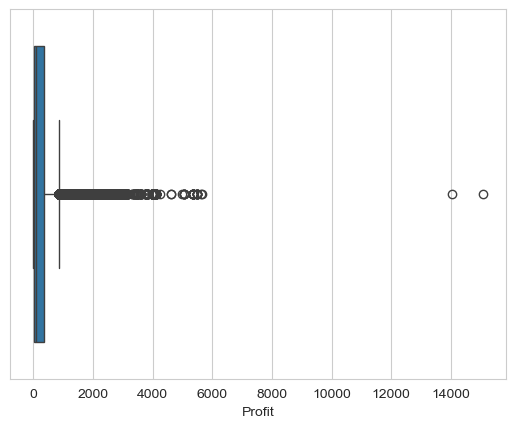

In [141]:
sns.boxplot(x=data.Profit)
plt.show()

In [142]:
df = data[data.Profit<=4000]

In [143]:
df

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260


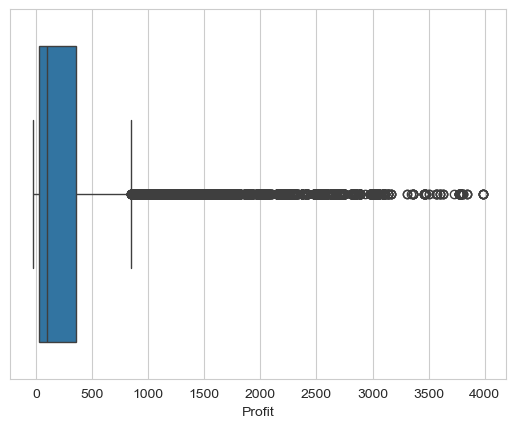

In [144]:
sns.boxplot(x=df.Profit)
plt.show()

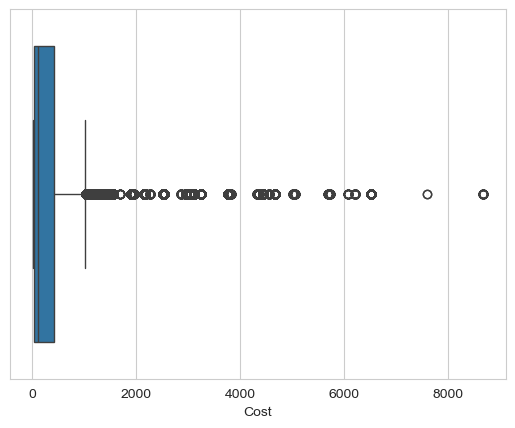

In [145]:
sns.boxplot(x= df.Cost)
plt.show()

In [146]:
df = df[df.Cost<=4000]
df.shape

(111365, 18)

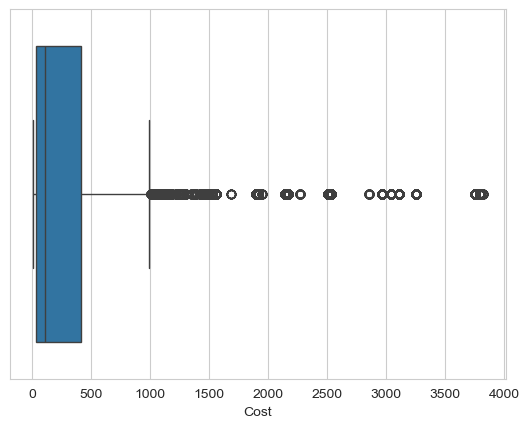

In [147]:
sns.boxplot(x=df.Cost)
plt.show()

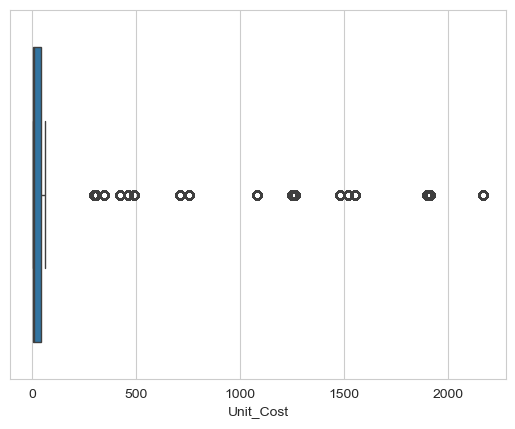

In [148]:
sns.boxplot(x=df.Unit_Cost)
plt.show()

In [149]:
df=df[df.Unit_Cost<=2000]
df.shape

(109123, 18)

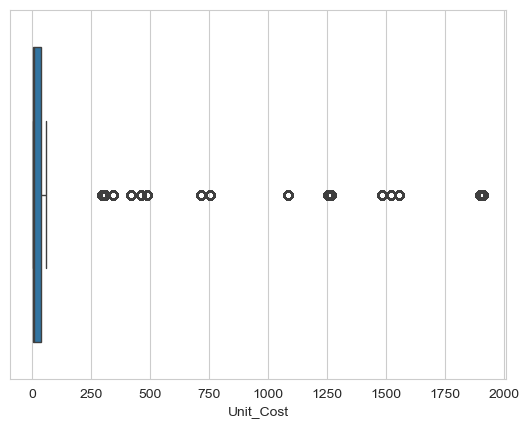

In [150]:
sns.boxplot(x=df.Unit_Cost)
plt.show()

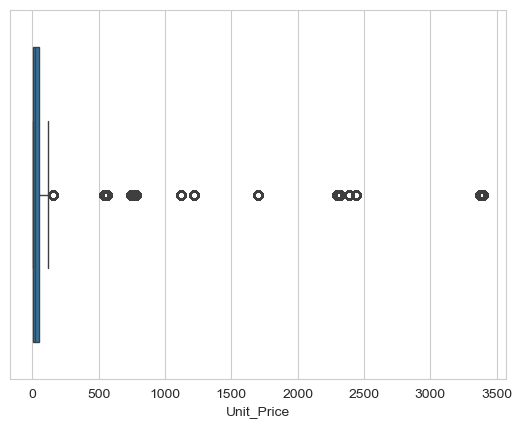

In [151]:
sns.boxplot(x=df.Unit_Price)
plt.show()

In [152]:
df = df[df.Unit_Price<=3000]
df.shape

(108627, 18)

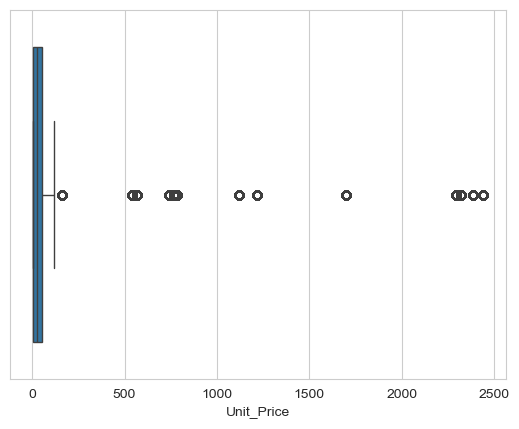

In [153]:
sns.boxplot(x = df.Unit_Price)
plt.show()

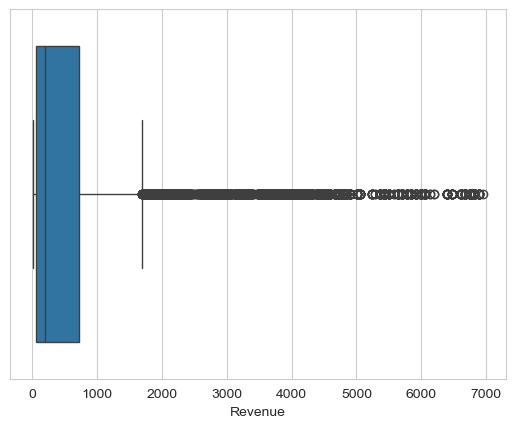

In [154]:
sns.boxplot(x=df.Revenue)
plt.show()

In [155]:
df= df[df.Revenue<=3000]
df.shape

(105772, 18)

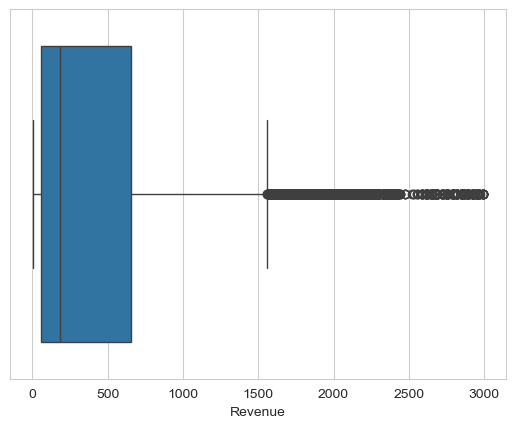

In [156]:
sns.boxplot(x=df.Revenue)
plt.show()

# EDA

In [157]:
corr = df.corr(numeric_only=True)
corr

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
Day,1.000000,-0.004826,-0.014564,-0.000658,-0.003262,-0.003240,-0.001663,-0.004422,-0.003595
Year,-0.004826,1.000000,0.034252,0.089759,-0.165236,-0.160775,-0.118555,-0.173307,-0.161671
Customer_Age,-0.014564,0.034252,1.000000,0.021466,-0.006889,-0.005470,0.030976,0.003825,0.014599
Order_Quantity,-0.000658,0.089759,0.021466,1.000000,-0.490313,-0.487823,-0.097660,-0.303566,-0.240396
Unit_Cost,-0.003262,-0.165236,-0.006889,-0.490313,1.000000,0.996908,0.675990,0.877879,0.848284
Unit_Price,-0.003240,-0.160775,-0.005470,-0.487823,0.996908,1.000000,0.692948,0.871935,0.850917
Profit,-0.001663,-0.118555,0.030976,-0.097660,0.675990,0.692948,1.000000,0.779087,0.908442
Cost,-0.004422,-0.173307,0.003825,-0.303566,0.877879,0.871935,0.779087,1.000000,0.969813
Revenue,-0.003595,-0.161671,0.014599,-0.240396,0.848284,0.850917,0.908442,0.969813,1.000000


# Data Visulization

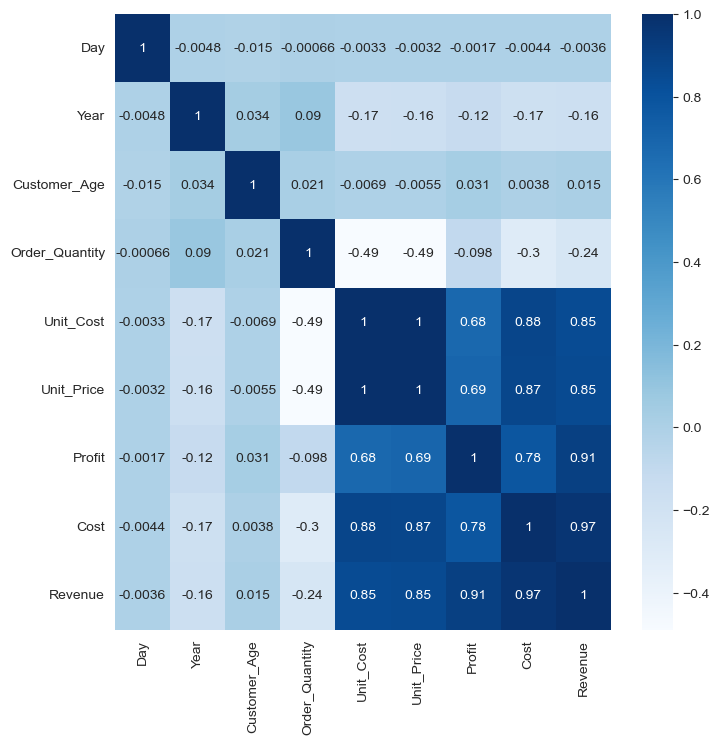

In [158]:
cp = sns.heatmap(corr,cmap='Blues', annot=True)
plt.gcf().set_size_inches(8,8)
plt.show()

* Here heatmap indicates:
* Unit cost and Unit price have correlation = 1 it means very highly correlated.
* Cost and Revenue also have very high correlation (0.97).
* Profit and Revenue correlation is 0.91.
* order quantity has negative correlation with unit cost and unit price(-0.49)

In [159]:
df.duplicated().sum()

np.int64(965)

In [160]:
df=df.drop_duplicates()
df.shape

(104807, 18)

In [161]:
df.dtypes

Date                object
Day                  int64
Month               object
Year                 int64
Customer_Age         int64
Age_Group           object
Customer_Gender     object
Country             object
State               object
Product_Category    object
Sub_Category        object
Product             object
Order_Quantity       int64
Unit_Cost            int64
Unit_Price           int64
Profit               int64
Cost                 int64
Revenue              int64
dtype: object

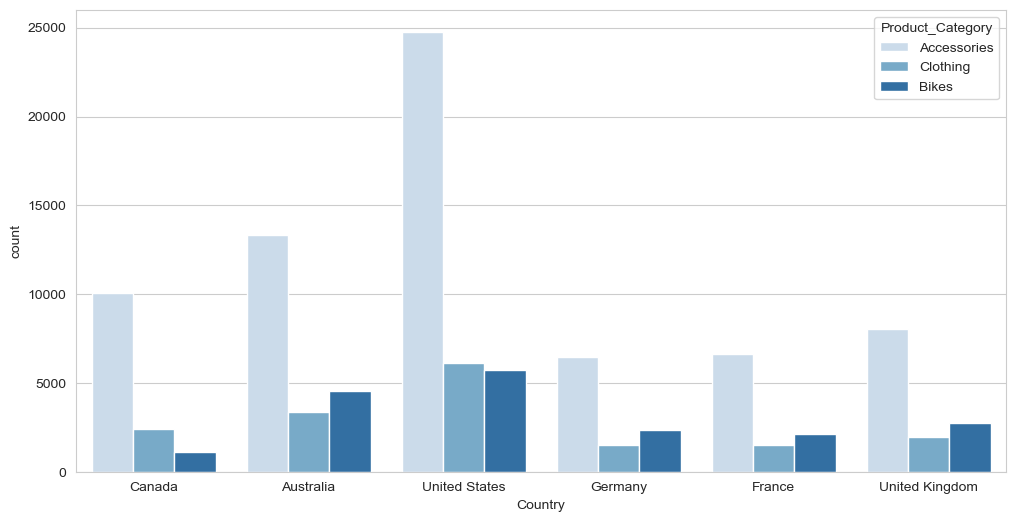

In [162]:
df.groupby(['Country', 'Product_Category'])['Revenue'].sum()
sns.countplot(data = df, x='Country', hue='Product_Category', palette=('Blues'))
plt.savefig('product11.jpg')
plt.gcf().set_size_inches(12,6)
plt.show()

* According to this graph
* United States has highest sales it means US market contributes the highest number of product sales
* Accessories dominate in every country it means accessories have highest demand
* Australia performs also well after US

In [163]:
df['Product_Category'].value_counts()

Product_Category
Accessories    69298
Bikes          18581
Clothing       16928
Name: count, dtype: int64

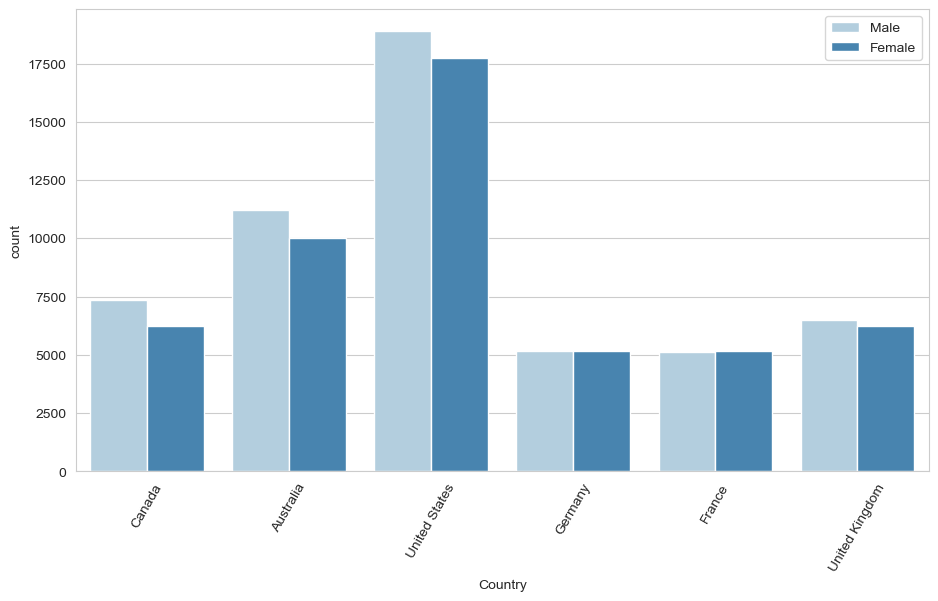

In [164]:
sns.countplot(data = df, x='Country', hue='Customer_Gender',palette=('Blues'))
plt.xticks(rotation=60)
sns.set_style("whitegrid")
plt.legend(['Male', 'Female'])
plt.gcf().set_size_inches(11,6)
plt.savefig('gender2,.jpg')
plt.show()

* According to this graph
* United states has highest customers/orders
* Male customers slightly higher it means male customers purchase slightly more than female but the difference is not huge.
* Australia is scond highest

In [165]:
df_age = df['Customer_Age'].value_counts()
df_age

Customer_Age
31    4094
34    3913
32    3814
29    3806
33    3742
      ... 
86       8
87       6
76       6
80       6
82       4
Name: count, Length: 70, dtype: int64

In [166]:
bikes_df = df[df["Product_Category"]=="Bikes"]
bikes_df

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
49334,2013-08-13,13,August,2013,18,Youth (<25),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",1,1266,2320,1008,1266,2274
49336,2013-09-10,10,September,2013,18,Youth (<25),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",1,1266,2320,1008,1266,2274
49337,2015-09-10,10,September,2015,18,Youth (<25),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",1,1266,2320,1008,1266,2274
49338,2013-10-20,20,October,2013,18,Youth (<25),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",1,1266,2320,1008,1266,2274
49340,2013-12-21,21,December,2013,18,Youth (<25),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",1,1266,2320,1008,1266,2274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112063,2016-04-22,22,April,2016,20,Youth (<25),M,Australia,New South Wales,Bikes,Touring Bikes,"Touring-3000 Blue, 54",3,461,742,554,1383,1937
112064,2013-12-05,5,December,2013,37,Adults (35-64),F,United Kingdom,England,Bikes,Touring Bikes,"Touring-1000 Blue, 54",1,1482,2384,807,1482,2289
112066,2014-01-18,18,January,2014,37,Adults (35-64),F,United Kingdom,England,Bikes,Touring Bikes,"Touring-1000 Blue, 54",1,1482,2384,807,1482,2289
112068,2014-02-27,27,February,2014,37,Adults (35-64),F,United Kingdom,England,Bikes,Touring Bikes,"Touring-1000 Blue, 54",1,1482,2384,807,1482,2289


In [167]:
rs = bikes_df.groupby('Customer_Gender')['Sub_Category'].value_counts()
rs

Customer_Gender  Sub_Category  
F                Road Bikes        4099
                 Mountain Bikes    3398
                 Touring Bikes     1634
M                Road Bikes        4499
                 Mountain Bikes    3297
                 Touring Bikes     1654
Name: count, dtype: int64

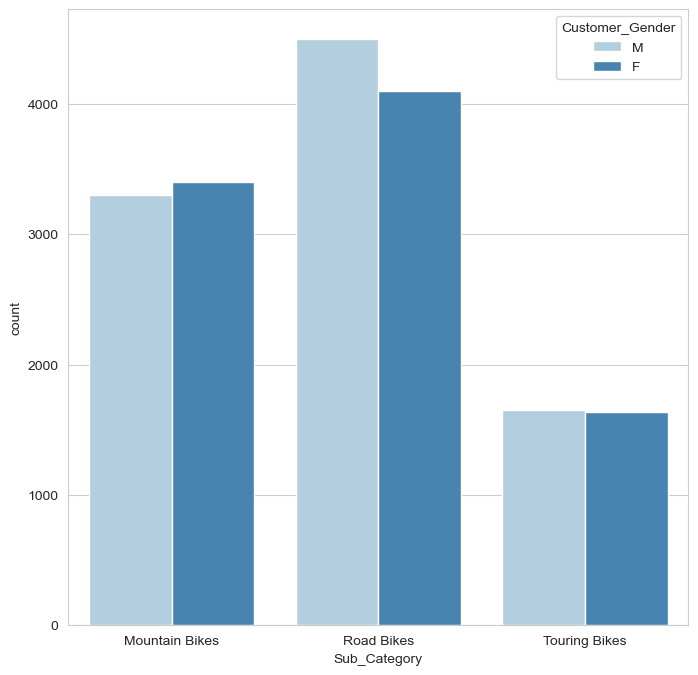

In [168]:
fig, rs = plt.subplots(figsize=(8,8))
rs = bikes_df.groupby('Customer_Gender')['Sub_Category'].value_counts()
plt.savefig('Customer_Gender.jpg')
sns.countplot(data = bikes_df, x='Sub_Category', hue='Customer_Gender',palette=('Blues'))
plt.show()

* Here the graph show
* GenderWise bikes category which is the most popular category bikes are like
* Road bikes are most popular
* Mountain bikes are also highly purchased it slightly lower count than road bikes
* Touring bikes have lowest sales
* Male and Female purchases are very similar but male slightly higher in road bikes and female slightly higher in mountain bikes

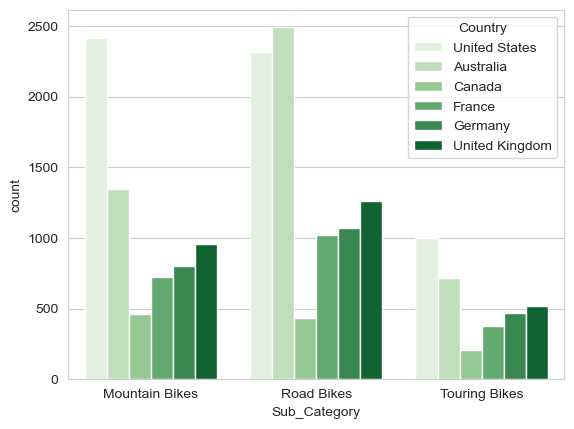

In [169]:
rs = bikes_df.groupby('Country')['Sub_Category'].value_counts()
plt.savefig('country1.jpg')
sns.countplot(data = bikes_df, x='Sub_Category', hue='Country',palette=('Greens'))
plt.show()

* According to this graph
* Mountains bikes and road bikes are most popular.It means more customers purchased mountain and road bikes.
* United states has highest sales. So US customers purchased the most bikes
* Touring bikes bar are smaller in every country. It means fewer sales/orders for Touring bikes
* Some countries have similar patterns - like(Germany,UK,France) 

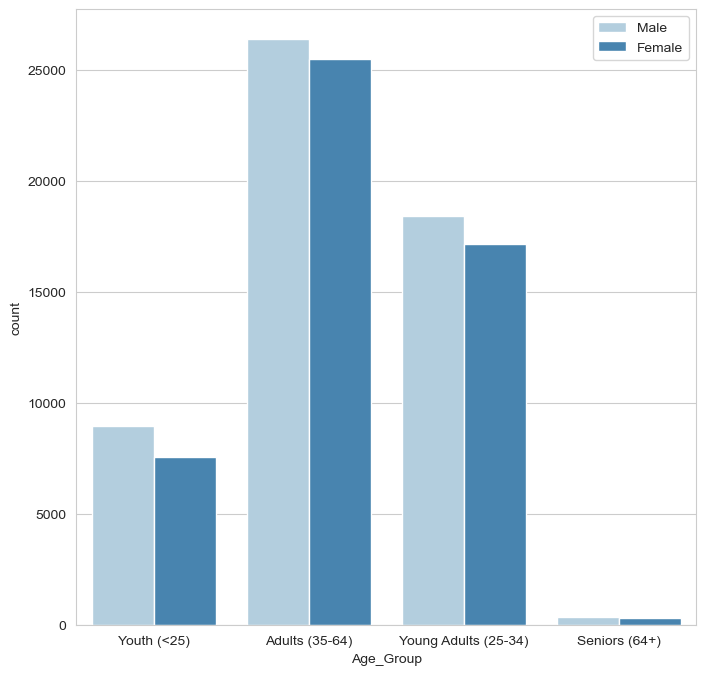

<Figure size 640x480 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

In [170]:
sns.countplot(data = df, x='Age_Group', hue='Customer_Gender',palette=('Blues'))
plt.xticks(rotation=0)
sns.set_style("whitegrid")
plt.legend(['Male', 'Female'])
plt.gcf().set_size_inches(8,8)
plt.show()
plt.savefig('Age_Group whith gender.jpg')
plt.figure(figsize=(10,10))
plt.show()

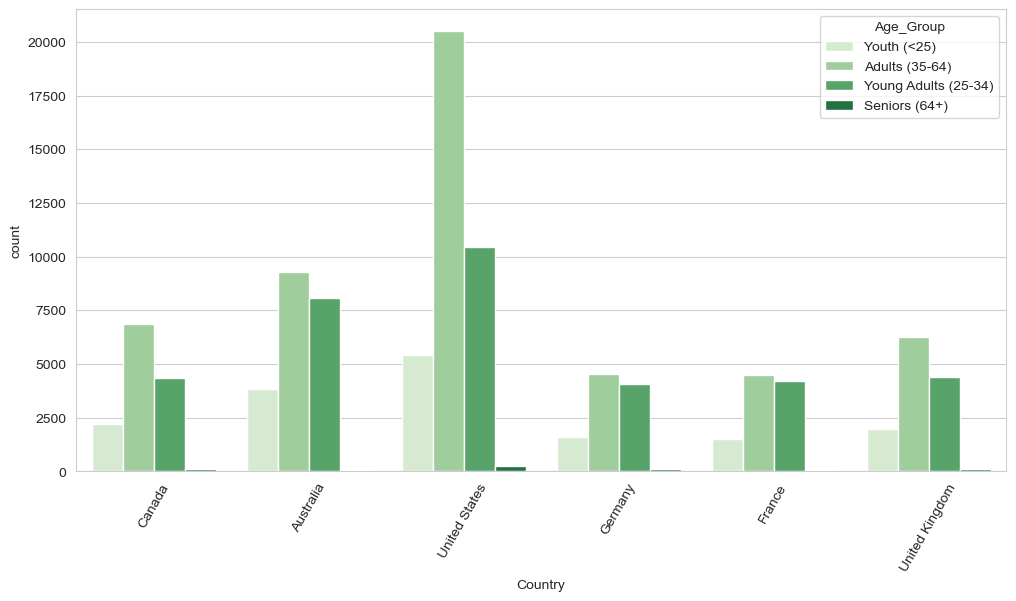

In [171]:
sns.countplot(data = df, x='Country', hue='Age_Group',palette=('Greens'))
plt.xticks(rotation=60)
sns.set_style("whitegrid")
plt.gcf().set_size_inches(12,6)
plt.savefig('country.jpg')
plt.show()

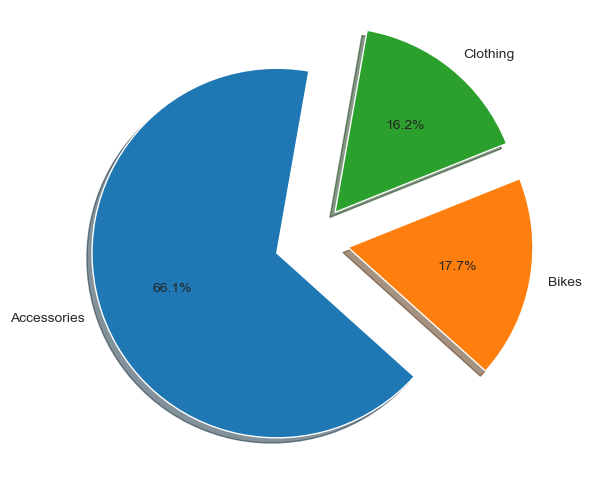

In [172]:
df_product = df['Product_Category'].value_counts()
label= [df_product.index.tolist()]
plt.pie(df_product, shadow=True,labels=label[0],explode=(0.2, 0.2, 0.2), autopct='%1.1f%%', startangle=80)
plt.gcf().set_size_inches(12,6)
plt.savefig('product.jpg')
plt.show()

* Here the pie chart shows the distribution of product categories
* Accessories contribute the largest share of total sales/order
* Clothing and bikes contribute smaller portion

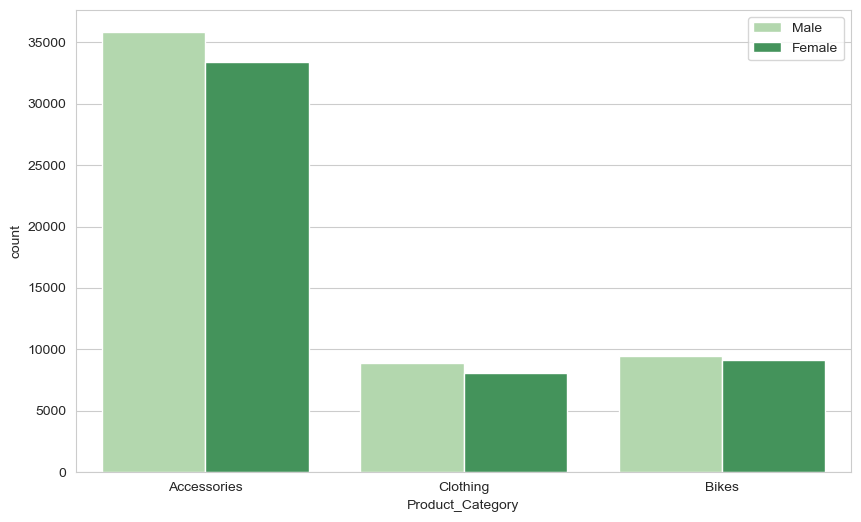

In [173]:
sns.countplot(data = df, x='Product_Category', hue='Customer_Gender', palette=('Greens'))
plt.xticks(rotation=0)
sns.set_style("whitegrid")
plt.legend(['Male', 'Female'])
plt.gcf().set_size_inches(10,6)
plt.savefig('customer.jpg')
plt.show()

In [174]:
bikes_df

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
49334,2013-08-13,13,August,2013,18,Youth (<25),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",1,1266,2320,1008,1266,2274
49336,2013-09-10,10,September,2013,18,Youth (<25),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",1,1266,2320,1008,1266,2274
49337,2015-09-10,10,September,2015,18,Youth (<25),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",1,1266,2320,1008,1266,2274
49338,2013-10-20,20,October,2013,18,Youth (<25),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",1,1266,2320,1008,1266,2274
49340,2013-12-21,21,December,2013,18,Youth (<25),M,United States,California,Bikes,Mountain Bikes,"Mountain-200 Silver, 38",1,1266,2320,1008,1266,2274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112063,2016-04-22,22,April,2016,20,Youth (<25),M,Australia,New South Wales,Bikes,Touring Bikes,"Touring-3000 Blue, 54",3,461,742,554,1383,1937
112064,2013-12-05,5,December,2013,37,Adults (35-64),F,United Kingdom,England,Bikes,Touring Bikes,"Touring-1000 Blue, 54",1,1482,2384,807,1482,2289
112066,2014-01-18,18,January,2014,37,Adults (35-64),F,United Kingdom,England,Bikes,Touring Bikes,"Touring-1000 Blue, 54",1,1482,2384,807,1482,2289
112068,2014-02-27,27,February,2014,37,Adults (35-64),F,United Kingdom,England,Bikes,Touring Bikes,"Touring-1000 Blue, 54",1,1482,2384,807,1482,2289


In [175]:
max_price = bikes_df.groupby('Country')[['Sub_Category','Unit_Price']].max()
max_price

,Sub_Category,Unit_Price
Country,,
Australia,Touring Bikes,2443
Canada,Touring Bikes,2443
France,Touring Bikes,2443
Germany,Touring Bikes,2443
United Kingdom,Touring Bikes,2443
United States,Touring Bikes,2443


* Here appears every where is expensive bike belongs to touring bikes category
* The highest priced bike available in each country costs 2443

In [176]:
most_years = bikes_df.groupby('Year')[['Sub_Category','Unit_Price']].sum()
most_years

,Sub_Category,Unit_Price
Year,,
2011,Mountain BikesMountain BikesMountain BikesMoun...,2113206
2012,Mountain BikesMountain BikesMountain BikesMoun...,1059535
2013,Mountain BikesMountain BikesMountain BikesMoun...,7697797
2014,Mountain BikesMountain BikesMountain BikesMoun...,6577368
2015,Mountain BikesMountain BikesMountain BikesMoun...,5649148
2016,Mountain BikesMountain BikesMountain BikesMoun...,4858186


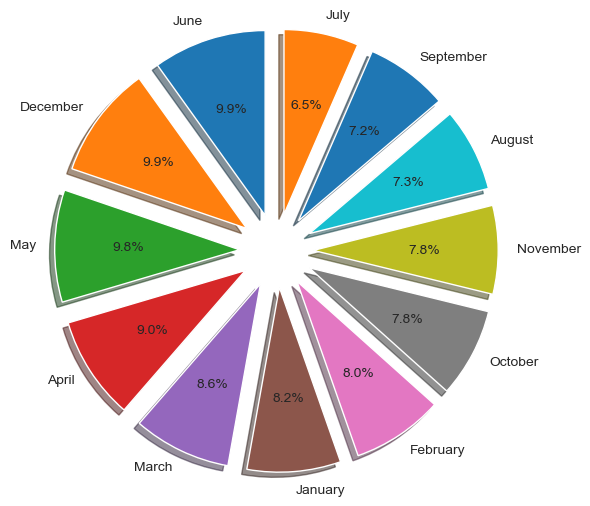

In [177]:
df_product_month = df['Month'].value_counts()
label= [df_product_month.index.tolist()]
plt.pie(df_product_month, shadow=True, labels=label[0],
explode=(0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2),autopct='%1.1f%%', startangle=90)
plt.gcf().set_size_inches(12,6)
plt.savefig(' based on Month.jpg')
plt.show()

* Here Pie chart shows what percentage of total records/orders happened in that month.
* June, December and May these months have the Largest share of orders/sales
* Lowest month is July it means fewer order/sales in july.

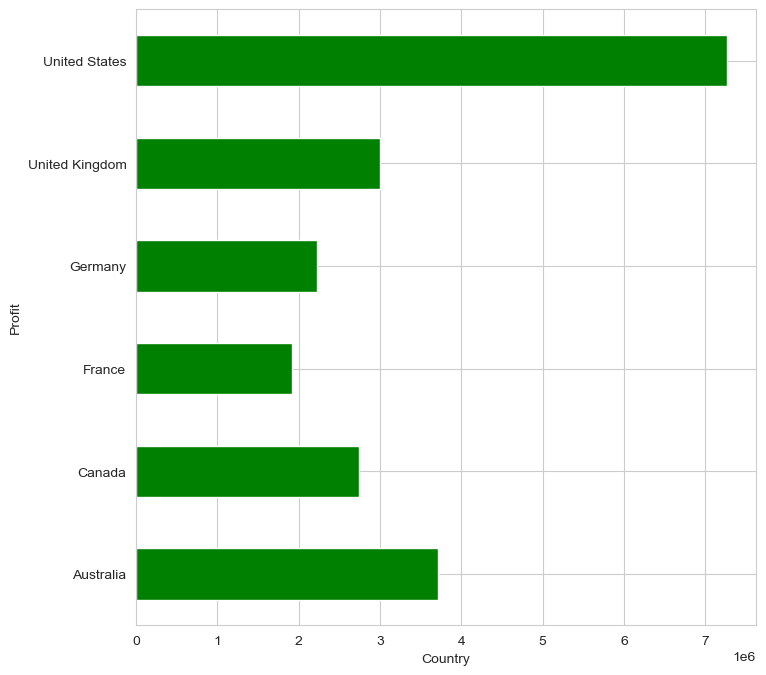

In [178]:
plt.figure(figsize=(8,8))
ax = df.groupby('Country')['Profit'].sum().plot(kind='barh',color='green')
ax.set(ylabel='Profit', xlabel='Country')
plt.show()

# Data Preprocessing

## Feature Selection

In [179]:
df.columns

Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Profit', 'Cost', 'Revenue'],
      dtype='object')

In [180]:
df.drop(columns = ['Order_Quantity','Unit_Price','Unit_Cost','Revenue'], inplace = True)

In [181]:
df.columns

Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Profit', 'Cost'],
      dtype='object')

In [182]:
bike = df.select_dtypes(exclude = ['object']).copy()

In [183]:
bike

,Day,Year,Customer_Age,Profit,Cost
0,26,2013,19,590,360
1,26,2015,19,590,360
2,23,2014,49,1366,1035
3,23,2016,49,1188,900
4,15,2014,47,238,180
...,...,...,...,...,...
113031,12,2016,41,112,72
113032,2,2014,18,655,528
113033,2,2016,18,655,528
113034,4,2014,37,684,576


In [184]:
bike['Customer_Age'] = df['Customer_Age']

In [185]:
bike['Customer_Gender'] = df['Customer_Gender']

In [186]:
bike['Country'] = df['Country']

In [187]:
bike['Product_Category'] = df['Product_Category']

In [188]:
bike

,Day,Year,Customer_Age,Profit,Cost,Customer_Gender,Country,Product_Category
0,26,2013,19,590,360,M,Canada,Accessories
1,26,2015,19,590,360,M,Canada,Accessories
2,23,2014,49,1366,1035,M,Australia,Accessories
3,23,2016,49,1188,900,M,Australia,Accessories
4,15,2014,47,238,180,F,Australia,Accessories
...,...,...,...,...,...,...,...,...
113031,12,2016,41,112,72,M,United Kingdom,Clothing
113032,2,2014,18,655,528,M,Australia,Clothing
113033,2,2016,18,655,528,M,Australia,Clothing
113034,4,2014,37,684,576,F,France,Clothing


In [189]:
bike = pd.get_dummies(bike)

In [190]:
bike

,Day,Year,Customer_Age,Profit,Cost,Customer_Gender_F,Customer_Gender_M,Country_Australia,Country_Canada,Country_France,Country_Germany,Country_United Kingdom,Country_United States,Product_Category_Accessories,Product_Category_Bikes,Product_Category_Clothing
0,26,2013,19,590,360,False,True,False,True,False,False,False,False,True,False,False
1,26,2015,19,590,360,False,True,False,True,False,False,False,False,True,False,False
2,23,2014,49,1366,1035,False,True,True,False,False,False,False,False,True,False,False
3,23,2016,49,1188,900,False,True,True,False,False,False,False,False,True,False,False
4,15,2014,47,238,180,True,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,12,2016,41,112,72,False,True,False,False,False,False,True,False,False,False,True
113032,2,2014,18,655,528,False,True,True,False,False,False,False,False,False,False,True
113033,2,2016,18,655,528,False,True,True,False,False,False,False,False,False,False,True
113034,4,2014,37,684,576,True,False,False,False,True,False,False,False,False,False,True


In [191]:
bike.shape

(104807, 16)

In [192]:
bike.columns

Index(['Day', 'Year', 'Customer_Age', 'Profit', 'Cost', 'Customer_Gender_F',
       'Customer_Gender_M', 'Country_Australia', 'Country_Canada',
       'Country_France', 'Country_Germany', 'Country_United Kingdom',
       'Country_United States', 'Product_Category_Accessories',
       'Product_Category_Bikes', 'Product_Category_Clothing'],
      dtype='object')

## Model Training

In [193]:
X= bike.drop('Profit',axis=1)
y= bike['Profit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [194]:
X_train

,Day,Year,Customer_Age,Cost,Customer_Gender_F,Customer_Gender_M,Country_Australia,Country_Canada,Country_France,Country_Germany,Country_United Kingdom,Country_United States,Product_Category_Accessories,Product_Category_Bikes,Product_Category_Clothing
3317,19,2016,43,75,True,False,False,False,False,True,False,False,True,False,False
95132,25,2016,32,14,True,False,True,False,False,False,False,False,True,False,False
8638,29,2013,40,60,True,False,False,False,False,False,False,True,True,False,False
97133,7,2013,22,4,True,False,False,True,False,False,False,False,True,False,False
56635,30,2016,40,924,True,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56877,5,2015,30,1266,True,False,False,True,False,False,False,False,False,True,False
84223,18,2015,29,45,True,False,True,False,False,False,False,False,True,False,False
111906,6,2014,40,461,True,False,False,False,False,False,False,True,False,True,False
874,13,2014,51,354,False,True,True,False,False,False,False,False,True,False,False


In [195]:
y_train

3317       121
95132       14
8638        57
97133        4
56635      737
          ... 
56877     1031
84223       54
111906     266
874        400
16023       66
Name: Profit, Length: 83845, dtype: int64

In [196]:
X_test

,Day,Year,Customer_Age,Cost,Customer_Gender_F,Customer_Gender_M,Country_Australia,Country_Canada,Country_France,Country_Germany,Country_United Kingdom,Country_United States,Product_Category_Accessories,Product_Category_Bikes,Product_Category_Clothing
16027,26,2013,40,63,True,False,True,False,False,False,False,False,True,False,False
42870,13,2013,22,525,False,True,False,False,False,False,False,True,True,False,False
25895,28,2016,34,64,True,False,True,False,False,False,False,False,True,False,False
55293,21,2016,59,420,True,False,False,False,False,False,True,False,False,True,False
79583,16,2016,45,126,False,True,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5610,16,2016,26,108,True,False,False,False,False,False,False,True,True,False,False
16348,12,2015,24,32,True,False,True,False,False,False,False,False,True,False,False
75346,25,2013,57,25,False,True,False,True,False,False,False,False,True,False,False
57473,10,2016,42,1252,False,True,False,False,True,False,False,False,False,True,False


In [197]:
X_test.replace({True:1,False:0},inplace = True)

In [198]:
X_train.replace({True:1,False:0}, inplace = True)

In [199]:
X_train

,Day,Year,Customer_Age,Cost,Customer_Gender_F,Customer_Gender_M,Country_Australia,Country_Canada,Country_France,Country_Germany,Country_United Kingdom,Country_United States,Product_Category_Accessories,Product_Category_Bikes,Product_Category_Clothing
3317,19,2016,43,75,1,0,0,0,0,1,0,0,1,0,0
95132,25,2016,32,14,1,0,1,0,0,0,0,0,1,0,0
8638,29,2013,40,60,1,0,0,0,0,0,0,1,1,0,0
97133,7,2013,22,4,1,0,0,1,0,0,0,0,1,0,0
56635,30,2016,40,924,1,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56877,5,2015,30,1266,1,0,0,1,0,0,0,0,0,1,0
84223,18,2015,29,45,1,0,1,0,0,0,0,0,1,0,0
111906,6,2014,40,461,1,0,0,0,0,0,0,1,0,1,0
874,13,2014,51,354,0,1,1,0,0,0,0,0,1,0,0


# Linear Regression

In [200]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [201]:
lr.score(X_train,y_train)

0.6380235130422818

In [202]:
lr.score(X_test,y_test)

0.6380738418001738

In [203]:
pred = lr.predict(X_test)

In [204]:
print(pred)

[ 66.82228251 361.27076206  71.42346877 ... 138.89632034 618.87972857
 132.93423303]


* Here model explains about 63.8%
* so here model performance is good and acceptable

# Ridge Regression

In [205]:
lr_model_ridge = Ridge(alpha = 1)
lr_model_ridge.fit(X_train, y_train)

Ridge(alpha=1)

In [206]:
pred_ridge = lr_model_ridge.predict(X_test)

In [207]:
lr_model_ridge.score(X_train,y_train)

0.6380235128215618

In [208]:
lr_model_ridge.score(X_test,y_test)

0.6380738205798695

In [209]:
pred = lr_model_ridge.predict(X_test)

In [210]:
print(pred_ridge)

[ 66.8237371  361.26489279  71.42532886 ... 138.89239012 618.88440488
 132.92965027]


* This is almost same as Linear Regression
* It means ridge did not improve much
* But it made the model more stable

# Polynomial Regression

## Use polynomial festure(degree = 2)

In [211]:
poly = PolynomialFeatures(degree=2) 

X_train_poly = poly.fit_transform(X_train.values)
X_test_poly = poly.transform(X_test.values)

In [212]:
lm_poly = LinearRegression()
lm_poly.fit(X_train_poly,y_train)

LinearRegression()

In [213]:
lm_poly.score (X_train_poly,y_train)

0.812780634454756

* Polynomial Regression captures non linear relationships
* so the model becomes more flexible and predicts better.

## Use polynomial festure(degree = 3)

In [214]:
poly3 = PolynomialFeatures(degree=3) 

X_train_poly3 = poly3.fit_transform(X_train.values)
X_test_poly3 = poly3.transform(X_test.values)

In [215]:
lm_poly3 = LinearRegression()
lm_poly3.fit(X_train_poly3,y_train)

LinearRegression()

In [216]:
lm_poly3.score (X_train_poly3,y_train)

0.8278462055027946

* This is slightly better than degree 2
* Here model more complex patterns.

# Lasso Regression

In [217]:
lasso_model = Lasso(alpha = 1)
lasso_model.fit(X_train , y_train)

Lasso(alpha=1)

In [218]:
lasso_model.score(X_train,y_train)

0.6369779417825966

In [219]:
lasso_model.score(X_test,y_test)

0.63720405478019

* Here Lasso performance similar to Linear Regression
* It also peforms featur selection by reducing some coefficients to zero  

# Decision Tree Regressor

In [220]:
from sklearn.tree import DecisionTreeRegressor

In [221]:
dt = DecisionTreeRegressor(random_state =100,max_depth=8) 

In [222]:
dt.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=8, random_state=100)

In [223]:
dt.score(X_train,y_train)

0.8672908425218615

In [224]:
dt.score(X_test,y_test)

0.8645105349910627

* DecisionTreeRegressor is my best model so far

# Why this is Excellent

* Train score and test score are almost equal
* No major overfitting
* model capture complex relationships well